# **County Propensity Score Calculation**

This notebook calculates county-level solar siting propensity scores using regression coefficients from the Capacity Intensity results table.

It creates two versions of the score:

- **Social-component score:** uses only the significant socio-political terms from the expanded model
- **Full propensity score:** uses both significant techno-economic and socio-political terms from the expanded model

Important: the social-component score is a constructed subset of the expanded model, not a separately estimated “social-only” regression.

The notebook:
- loads county-level data from the Solar-NIMBY repo
- merges techno-economic and socio-political variables by county GEOID
- computes raw predicted values using the regression coefficients
- normalizes the raw values into 0–1 propensity scores
- exports two CSV files for later backtesting / model input

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [ ]:
basepath = Path("../Solar-NIMBY/data")

tech_path = basepath / "suitability_scores" / "suitability_scores_county.csv"
social_path = basepath / "county_clean" / "social_factors_merged.csv"
gdp_path = basepath / "GDP_percapita.csv"

print("Tech path exists:", tech_path.exists(), tech_path)
print("Social path exists:", social_path.exists(), social_path)
print("GDP path exists:", gdp_path.exists(), gdp_path)

Tech path exists: True ../Solar-NIMBY/data/suitability_scores/suitability_scores_county.csv
Social path exists: True ../Solar-NIMBY/data/county_clean/social_factors_merged.csv
GDP path exists: True ../Solar-NIMBY/data/GDP_percapita.csv


In [3]:
tech = pd.read_csv(tech_path, dtype=str)
social = pd.read_csv(social_path, dtype=str)
gdp = pd.read_csv(gdp_path, dtype=str)

print("tech shape:", tech.shape)
print("social shape:", social.shape)
print("gdp shape:", gdp.shape)

display(tech.head())
display(social.head())
display(gdp.head())

tech shape: (3233, 9)
social shape: (3125, 66)
gdp shape: (3041, 4)


,GHI,Protected_Land,Habitat,Slope,Population_Density,Distance_to_Substation,Land_Cover,County Name,State
0,15.0,91.54783467808332,33.74828475767056,91.02952961194357,98.63411822822329,53.24167078324826,67.86096931774522,Ballard,Kentucky
1,15.0,99.58368523026479,82.84067762929108,71.72398032689155,96.68289532515277,60.58298971632967,85.69119181280739,Bourbon,Kentucky
2,15.0,99.8961362692148,39.23642847251073,42.7597978119374,98.2395097631907,50.0,61.83963439966764,Butler,Kentucky
3,15.0,97.73388297263254,29.826520096186876,11.827321653498226,93.35279972518035,52.38005267376617,56.73794801328295,Estill,Kentucky
4,15.0,98.00082118661466,49.732293163621435,32.705892013960174,99.46684459043317,50.0,71.55528638883186,Fleming,Kentucky


,GEOID,State,County Name,area km2,area mi2,FIPS State,FIPS County,Wind Capacity Intensity (MW / 1000 sq mile),Wind Project Intensity (Projects / 1000 sq mile),Wind Avg Capacity Intensity (MW / 1000 sq mile),GDP_2017,GDP_2018,GDP_2019,GDP_2020,GDP_2021,GDP_2022,Solar MW 1000 sq mile all,Solar Projects 1000 sq mile all,Solar MW Avg 1000 sq mile all,Solar MW 1000 sq mile small,Solar Projects 1000 sq mile small,Solar MW Avg 1000 sq mile small,Solar MW 1000 sq mile medium,Solar Projects 1000 sq mile medium,Solar MW Avg 1000 sq mile medium,Solar MW 1000 sq mile large,Solar Projects 1000 sq mile large,Solar MW Avg 1000 sq mile large,No. of Private Schools,Median Income,Total Unemployment,Unemployment Rate,Hispanic/Latino,White,Black/African American,American Indian/Alaska Native,Asian,Native Hawaiian/Other Pacific Islander,Others,Number of Existing Installs,Total Installed Capacity (kW),Median Installed Capacity (kW),Total Installed Capacity (kW/ 1000 sq mile),Median Installed Capacity (kW / sq mile),Number of Existing Installs / sq mile,democrat_percentage_vote,republican_percentage_vote,green_percentage_vote,libertarian_percentage_vote,other_percentage_vote,18-24 Less than high school graduate,18-24 High school graduate,18-24 Some college or associate's degree,18-24 Bachelor's degree or higher,25+ Less than 9th grade,"25+ 9th to 12th grade, no diploma",25+ High school graduate,"25+ Some college, no degree",25+ Associate's degree,25+ Bachelor's degree,25+ Graduate or professional degree,25+ High school graduate or higher,25+ Bachelor's degree or higher,Electric Commercial Rate,Electric Industrial Rate,Electric Residential Rate
0,1001.0,Alabama,Autauga,1565.322757499382,604.3742473160263,01,001,NaN,NaN,NaN,29.49,29.91,28.96,28.82,28.91,32.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,62660,46577,2.8,0.036000340107133745,0.7071167417736587,0.19304480911487118,0.003128985630473599,0.014845676388062239,0.00037411784712184336,0.04382280418331775,12.0,227901.0,12.75,377085.89,0.02,0.02,0.27018365142239825,0.714368023046453,NaN,NaN,0.015448325531148721,9.9,33.4,45.4,11.3,2.0,8.4,32.8,19.6,9.1,16.4,11.7,89.6,28.1,0.121895086554537,0.0636515383525151,0.1350567137682845
1,1003.0,Alabama,Baldwin,4352.548564209735,1680.527705738507,01,003,NaN,NaN,NaN,29.96,31.48,33.07,32.88,35.46,36.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,64346,183804,3.7,0.05473600642024102,0.8046658929010602,0.07766852054002511,0.00557024943154116,0.008754481871879948,0.0005263907286196913,0.04628355201560188,35.0,1123484.25,14.5,668530.63,0.01,0.02,0.22409029987509005,0.7617137282433283,NaN,NaN,0.014195971881581707,14.4,39.1,38.4,8.1,2.1,6.9,27.4,21.7,9.5,20.6,11.8,91.0,32.5,0.121895086554537,0.0636515383525151,0.1350567137682845
2,1005.0,Alabama,Barbour,2342.545641813826,904.461557395602,01,005,NaN,NaN,NaN,30.83,31.33,30.87,29.61,30.27,30.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,36422,20639,8.6,0.05986599532173017,0.43951948618324543,0.46980930103476987,0.0022994885620267217,0.004083574515323316,0.0,0.023629227292550452,NaN,NaN,NaN,NaN,NaN,NaN,0.45788172656398557,0.5345122646891044,NaN,NaN,0.007606008746910059,23.2,40.3,33.1,3.5,7.4,16.9,36.7,20.5,7.3,6.7,4.4,75.7,11.2,0.121895086554537,0.0636515383525151,0.1350567137682845
3,1007.0,Alabama,Bibb,1622.295669819397,626.3716027086089,01,007,NaN,NaN,NaN,18.48,18.05,20.06,20.91,20.82,20.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54277,18333,9.7,0.03319427623020679,0.7375409321311622,0.19692280087919975,0.0017494280715919794,0.0011662853810613196,0.0004037141703673799,0.027631992105145112,0.0,305.0,18.75,486.93,0.03,0.0,0.20698280354351226,0.7842626367899947,NaN,NaN,0.008754559666492965,14.1,64.3,20.1,1.6,6.2,13.3,43.9,18.0,6.7,7.9,4.0,80.5,11.9,0.121895086554537,0.0636515383525151,0.1350567137682845
4,1009.0,Alabama,Blount,1685.0980704349663,650.6197351910813,01,009,NaN,NaN,NaN,16.6,17.59,17.05,15.24,17.23,17.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,52830,46871,6.0

,state,county,GDPpercapita,Population Estimate
0,Texas,Loving,120097.35,51
1,Texas,McMullen,1960.16,576
2,Texas,Glasscock,1861.93,1164
3,Texas,Martin,1337.95,5217
4,Texas,Upton,1251.21,3152


In [4]:
def clean_str_col(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

def pad_str(series, width):
    return clean_str_col(series).str.zfill(width)

def ensure_geoid_county(df, name):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    # Existing GEOID
    if "GEOID" in df.columns:
        df["GEOID"] = (
            clean_str_col(df["GEOID"])
            .str.replace("US", "", regex=False)
            .str.zfill(5)
            .str[:5]
        )
        return df

    # Other county ID columns
    for c in ["FIPS", "fips", "CountyFIPS", "COUNTY_FIPS", "county_fips", "GeoFIPS", "GEOIDFQ"]:
        if c in df.columns:
            df["GEOID"] = (
                clean_str_col(df[c])
                .str.replace("US", "", regex=False)
                .str.zfill(5)
                .str[:5]
            )
            return df

    # Build from state/county code columns
    state_candidates = ["STATEFP", "statefp", "State", "STATE", "FIPS State"]
    county_candidates = ["COUNTYFP", "countyfp", "County", "COUNTY", "FIPS County"]

    state_col = next((c for c in state_candidates if c in df.columns), None)
    county_col = next((c for c in county_candidates if c in df.columns), None)

    if state_col is not None and county_col is not None:
        df["GEOID"] = pad_str(df[state_col], 2) + pad_str(df[county_col], 3)
        return df

    # allow name-based merge later
    if "County Name" in df.columns and "State" in df.columns:
        return df

    raise KeyError(f"[{name}] Could not construct county GEOID. Columns: {list(df.columns)}")

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    return (s - s.min()) / (s.max() - s.min())

In [5]:
tech = ensure_geoid_county(tech, "tech")
social = ensure_geoid_county(social, "social")

# DO NOT run ensure_geoid_county on GDP file
gdp = gdp.copy()
gdp.columns = [c.strip() for c in gdp.columns]

print("tech GEOID present:", "GEOID" in tech.columns)
print("social GEOID present:", "GEOID" in social.columns)
print("gdp GEOID present:", "GEOID" in gdp.columns)

if "GEOID" in social.columns:
    display(social[["GEOID"]].head())
display(gdp.head())

tech GEOID present: False
social GEOID present: True
gdp GEOID present: False


,GEOID
0,01001
1,01003
2,01005
3,01007
4,01009


,state,county,GDPpercapita,Population Estimate
0,Texas,Loving,120097.35,51
1,Texas,McMullen,1960.16,576
2,Texas,Glasscock,1861.93,1164
3,Texas,Martin,1337.95,5217
4,Texas,Upton,1251.21,3152


In [ ]:
# Rename GDP columns
gdp = gdp.rename(columns={
    "state": "State",
    "county": "County Name",
    "GDPpercapita": "GDP_per_Capita"
})

# Clean county/state names to merge onto social
gdp["State"] = gdp["State"].astype(str).str.strip().str.lower()
gdp["County Name"] = gdp["County Name"].astype(str).str.strip().str.lower()

social["State"] = social["State"].astype(str).str.strip().str.lower()
social["County Name"] = social["County Name"].astype(str).str.strip().str.lower()

# Keep only the GDP columns needed
gdp_small = gdp[["State", "County Name", "GDP_per_Capita"]].copy()
gdp_small["GDP_per_Capita"] = pd.to_numeric(gdp_small["GDP_per_Capita"], errors="coerce")

# Merge GDP onto social by county/state
social = social.merge(
    gdp_small,
    on=["State", "County Name"],
    how="left"
)

print("GDP merge missing rate:", social["GDP_per_Capita"].isna().mean())
display(social[["GEOID", "County Name", "State", "GDP_per_Capita"]].head())

GDP merge missing rate: 0.02464


,GEOID,County Name,State,GDP_per_Capita
0,01001,autauga,alabama,28.91
1,01003,baldwin,alabama,35.46
2,01005,barbour,alabama,30.27
3,01007,bibb,alabama,20.82
4,01009,blount,alabama,17.23


In [7]:
# tech has no GEOID in the source file, so attach it using county/state names from social
tech["County Name"] = tech["County Name"].astype(str).str.strip().str.lower()
tech["State"] = tech["State"].astype(str).str.strip().str.lower()

geo_lookup = social[["GEOID", "County Name", "State"]].drop_duplicates()

tech_with_geoid = tech.merge(
    geo_lookup,
    on=["County Name", "State"],
    how="left"
)

print("Tech rows:", len(tech_with_geoid))
print("Missing GEOID in tech after merge:", tech_with_geoid["GEOID"].isna().sum())

display(tech_with_geoid.head())

Tech rows: 3240
Missing GEOID in tech after merge: 133


,GHI,Protected_Land,Habitat,Slope,Population_Density,Distance_to_Substation,Land_Cover,County Name,State,GEOID
0,15.0,91.54783467808332,33.74828475767056,91.02952961194357,98.63411822822329,53.24167078324826,67.86096931774522,ballard,kentucky,21007
1,15.0,99.58368523026479,82.84067762929108,71.72398032689155,96.68289532515277,60.58298971632967,85.69119181280739,bourbon,kentucky,21017
2,15.0,99.8961362692148,39.23642847251073,42.7597978119374,98.2395097631907,50.0,61.83963439966764,butler,kentucky,21031
3,15.0,97.73388297263254,29.826520096186876,11.827321653498226,93.35279972518035,52.38005267376617,56.73794801328295,estill,kentucky,21065
4,15.0,98.00082118661466,49.732293163621435,32.705892013960174,99.46684459043317,50.0,71.55528638883186,fleming,kentucky,21069


In [ ]:
# Techno-economic factors
TECH_COLS = {
    "GHI": "GHI",
    "Protected_Land": "Protected_Land",          
    "Slope": "Slope",
    "Population_Sparsity": "Population_Density" # closest processed county variable available
}

# Socio-political factors
SOCIO_COLS = {
    "Black": "Black/African American",
    "Asian": "Asian",
    "Income": "Median Income",
    "Grad_Education": "25+ Graduate or professional degree",
    "GDP_per_Capita": "GDP_per_Capita"
}

print("Techno-economic columns used:")
for k, v in TECH_COLS.items():
    print(f"  {k} -> {v}")

print("\nSocio-political columns used:")
for k, v in SOCIO_COLS.items():
    print(f"  {k} -> {v}")

Techno-economic columns used:
  GHI -> GHI
  Protected_Land -> Protected_Land
  Slope -> Slope
  Population_Sparsity -> Population_Density

Socio-political columns used:
  Black -> Black/African American
  Asian -> Asian
  Income -> Median Income
  Grad_Education -> 25+ Graduate or professional degree
  GDP_per_Capita -> GDP_per_Capita


In [9]:
tech_small = tech_with_geoid[["GEOID", "County Name", "State"] + list(TECH_COLS.values())].copy()
social_small = social[["GEOID", "County Name", "State"] + list(SOCIO_COLS.values())].copy()

df = social_small.merge(
    tech_small[["GEOID"] + list(TECH_COLS.values())],
    on="GEOID",
    how="left"
)

print("Merged rows:", len(df))
display(df.head())

Merged rows: 3275


,GEOID,County Name,State,Black/African American,Asian,Median Income,25+ Graduate or professional degree,GDP_per_Capita,GHI,Protected_Land,Slope,Population_Density
0,01001,autauga,alabama,0.19304480911487118,0.014845676388062239,62660,11.7,28.91,20.0,99.31800456799064,57.42490669043507,92.08957718232968
1,01003,baldwin,alabama,0.07766852054002511,0.008754481871879948,64346,11.8,35.46,20.0,88.6415074642447,91.48385952846611,81.16025930465071
2,01005,barbour,alabama,0.46980930103476987,0.004083574515323316,36422,4.4,30.27,20.0,94.05199818346958,66.47511731759008,98.44771798365123
3,01007,bibb,alabama,0.19692280087919975,0.0011662853810613196,54277,4.0,20.82,19.89209880495092,88.98087387964148,40.41824050362783,95.74890631668801
4,01009,blount,alabama,0.013968275442215985,0.002942469645212568,52830,5.6,17.23,15.0,99.79058964561325,38.62243700207288,92.47346469868386


In [10]:
df = df.rename(columns={
    "Black/African American": "Black",
    "Asian": "Asian",
    "Median Income": "Income",
    "25+ Graduate or professional degree": "Grad_Education",
    "GDP_per_Capita": "GDP_per_Capita",
    "GHI": "GHI",
    "Protected_Land": "Protected_Land",
    "Slope": "Slope",
    "Population_Density": "Population_Sparsity"
})

display(df.head())

,GEOID,County Name,State,Black,Asian,Income,Grad_Education,GDP_per_Capita,GHI,Protected_Land,Slope,Population_Sparsity
0,01001,autauga,alabama,0.19304480911487118,0.014845676388062239,62660,11.7,28.91,20.0,99.31800456799064,57.42490669043507,92.08957718232968
1,01003,baldwin,alabama,0.07766852054002511,0.008754481871879948,64346,11.8,35.46,20.0,88.6415074642447,91.48385952846611,81.16025930465071
2,01005,barbour,alabama,0.46980930103476987,0.004083574515323316,36422,4.4,30.27,20.0,94.05199818346958,66.47511731759008,98.44771798365123
3,01007,bibb,alabama,0.19692280087919975,0.0011662853810613196,54277,4.0,20.82,19.89209880495092,88.98087387964148,40.41824050362783,95.74890631668801
4,01009,blount,alabama,0.013968275442215985,0.002942469645212568,52830,5.6,17.23,15.0,99.79058964561325,38.62243700207288,92.47346469868386


In [11]:
numeric_cols = [
    "Black", "Asian", "Income", "Grad_Education", "GDP_per_Capita",
    "GHI", "Protected_Land", "Slope", "Population_Sparsity"
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

display(df[numeric_cols].describe())
print(df[numeric_cols].isna().mean().sort_values())

,Black,Asian,Income,Grad_Education,GDP_per_Capita,GHI,Protected_Land,Slope,Population_Sparsity
count,3142.000000,3142.000000,3141.000000,3142.000000,3090.000000,3275.000000,3275.000000,3275.000000,3275.000000
mean,0.085900,0.013262,58065.272843,8.131891,89.255508,17.531815,90.164373,70.436836,88.860067
std,0.140256,0.025601,15416.877527,4.705519,2160.882570,16.526350,13.577088,29.968248,18.979697
min,0.000000,0.000000,17109.000000,0.000000,10.270000,4.765299,2.379858,0.138137,10.000000
25%,0.004954,0.003149,48279.000000,5.100000,30.045000,5.000000,87.750973,49.527457,89.179630
50%,0.020208,0.005394,55769.000000,6.800000,40.470000,15.000000,95.967066,82.231837,97.062538
75%,0.096821,0.012162,64657.000000,9.800000,54.567500,20.000000,98.558283,96.087746,99.157989
max,0.871264,0.389100,156821.000000,49.100000,120097.350000,90.000000,100.000000,100.000000,100.000000


GHI                    0.000000
Protected_Land         0.000000
Slope                  0.000000
Population_Sparsity    0.000000
Black                  0.040611
Asian                  0.040611
Grad_Education         0.040611
Income                 0.040916
GDP_per_Capita         0.056489
dtype: float64


In [12]:
CONST = -52.397

# Socio-political-only coefficients
B_SOCIAL = {
    "Black": 0.877,
    "Asian": 0.449,
    "Income": 0.459,
    "Grad_Education": -0.495,
    "GDP_per_Capita": 0.810,
}

# Full model = techno-economic + socio-political
B_FULL = {
    "GHI": 0.902,
    "Protected_Land": 0.287,
    "Slope": 0.226,
    "Population_Sparsity": 0.191,
    "Black": 0.877,
    "Asian": 0.449,
    "Income": 0.459,
    "Grad_Education": -0.495,
    "GDP_per_Capita": 0.810,
}

In [13]:
def weighted_sum(frame, coef_dict, const=0.0):
    out = pd.Series(const, index=frame.index, dtype=float)
    for var, beta in coef_dict.items():
        out = out + beta * frame[var]
    return out

df["propensity_social_raw"] = weighted_sum(df, B_SOCIAL, const=CONST)
df["propensity_full_raw"] = weighted_sum(df, B_FULL, const=CONST)

display(df[[
    "GEOID", "County Name", "State",
    "propensity_social_raw", "propensity_full_raw"
]].head())

,GEOID,County Name,State,propensity_social_raw,propensity_full_raw
0,01001,autauga,alabama,28726.344566,28803.455971
1,01003,baldwin,alabama,29505.370646,29585.027720
2,01005,barbour,alabama,16688.055556,16766.915370
3,01007,bibb,alabama,24875.803425,24946.706172
4,01009,blount,alabama,24207.770871,24276.331873


In [14]:
df["social_score"] = minmax_scale(df["propensity_social_raw"])
df["full_score"] = minmax_scale(df["propensity_full_raw"])

display(df[[
    "GEOID", "County Name", "State",
    "social_score", "full_score"
]].head())

display(df[[
    "propensity_social_raw", "social_score",
    "propensity_full_raw", "full_score"
]].describe())

,GEOID,County Name,State,social_score,full_score
0,01001,autauga,alabama,0.325918,0.325887
1,01003,baldwin,alabama,0.338061,0.338073
2,01005,barbour,alabama,0.138285,0.138227
3,01007,bibb,alabama,0.265902,0.265757
4,01009,blount,alabama,0.255490,0.255306


,propensity_social_raw,social_score,propensity_full_raw,full_score
count,3040.000000,3040.000000,3040.000000,3040.000000
mean,26554.896428,0.292073,26629.899675,0.292000
std,6964.437917,0.108551,6961.241511,0.108532
min,7815.930959,0.000000,7901.024578,0.000000
25%,22044.304065,0.221769,22116.579975,0.221633
50%,25610.279415,0.277350,25687.060752,0.277300
75%,29559.962248,0.338911,29637.198877,0.338886
max,71974.381352,1.000000,72041.055411,1.000000


In [ ]:
df["county_name"] = (
    df["County Name"].astype(str).str.strip().str.title() + ", " +
    df["State"].astype(str).str.strip().str.title()
)

social_out = df[["county_name", "social_score"]].copy()
social_out = social_out.rename(columns={"social_score": "score"})
social_out = social_out.sort_values("score", ascending=False).reset_index(drop=True)

full_out = df[["county_name", "full_score"]].copy()
full_out = full_out.rename(columns={"full_score": "score"})
full_out = full_out.sort_values("score", ascending=False).reset_index(drop=True)

display(social_out.head(10))
display(full_out.head(10))

,county_name,score
0,"Loudoun, Virginia",1.000000
1,"Santa Clara, California",0.883191
2,"San Mateo, California",0.858968
3,"Marin, California",0.815908
4,"Howard, Maryland",0.805016
5,"Arlington, Virginia",0.795918
6,"Douglas, Colorado",0.789682
7,"San Francisco, California",0.783684
8,"Nassau, New York",0.783662
9,"Morris, New Jersey",0.763772


,county_name,score
0,"Loudoun, Virginia",1.000000
1,"Santa Clara, California",0.883590
2,"San Mateo, California",0.858807
3,"Marin, California",0.815635
4,"Howard, Maryland",0.804801
5,"Arlington, Virginia",0.795742
6,"Douglas, Colorado",0.789546
7,"Nassau, New York",0.783435
8,"San Francisco, California",0.783425
9,"Los Alamos, New Mexico",0.763879


In [16]:
social_csv = "county_propensity_scores_social_only.csv"
full_csv = "county_propensity_scores_full.csv"

social_out.to_csv(social_csv, index=False)
full_out.to_csv(full_csv, index=False)

print(f"Saved: {social_csv}")
print(f"Saved: {full_csv}")

Saved: county_propensity_scores_social_only.csv
Saved: county_propensity_scores_full.csv


In [17]:
print("Top 10 counties by social-only score")
display(social_out.head(10))

print("Bottom 10 counties by social-only score")
display(social_out.tail(10))

print("Top 10 counties by full score")
display(full_out.head(10))

print("Bottom 10 counties by full score")
display(full_out.tail(10))

Top 10 counties by social-only score


,county_name,score
0,"Loudoun, Virginia",1.000000
1,"Santa Clara, California",0.883191
2,"San Mateo, California",0.858968
3,"Marin, California",0.815908
4,"Howard, Maryland",0.805016
5,"Arlington, Virginia",0.795918
6,"Douglas, Colorado",0.789682
7,"San Francisco, California",0.783684
8,"Nassau, New York",0.783662
9,"Morris, New Jersey",0.763772


Bottom 10 counties by social-only score


,county_name,score
3265,"Keokuk, Iowa",NaN
3266,"Keokuk, Iowa",NaN
3267,"Keokuk, Iowa",NaN
3268,"Hamilton, Kansas",NaN
3269,"Hamilton, Kansas",NaN
3270,"Hamilton, Kansas",NaN
3271,"Hamilton, Kansas",NaN
3272,"Hamilton, Kansas",NaN
3273,"Hamilton, Kansas",NaN
3274,"Hamilton, Kansas",NaN


Top 10 counties by full score


,county_name,score
0,"Loudoun, Virginia",1.000000
1,"Santa Clara, California",0.883590
2,"San Mateo, California",0.858807
3,"Marin, California",0.815635
4,"Howard, Maryland",0.804801
5,"Arlington, Virginia",0.795742
6,"Douglas, Colorado",0.789546
7,"Nassau, New York",0.783435
8,"San Francisco, California",0.783425
9,"Los Alamos, New Mexico",0.763879


Bottom 10 counties by full score


,county_name,score
3265,"Keokuk, Iowa",NaN
3266,"Keokuk, Iowa",NaN
3267,"Keokuk, Iowa",NaN
3268,"Hamilton, Kansas",NaN
3269,"Hamilton, Kansas",NaN
3270,"Hamilton, Kansas",NaN
3271,"Hamilton, Kansas",NaN
3272,"Hamilton, Kansas",NaN
3273,"Hamilton, Kansas",NaN
3274,"Hamilton, Kansas",NaN


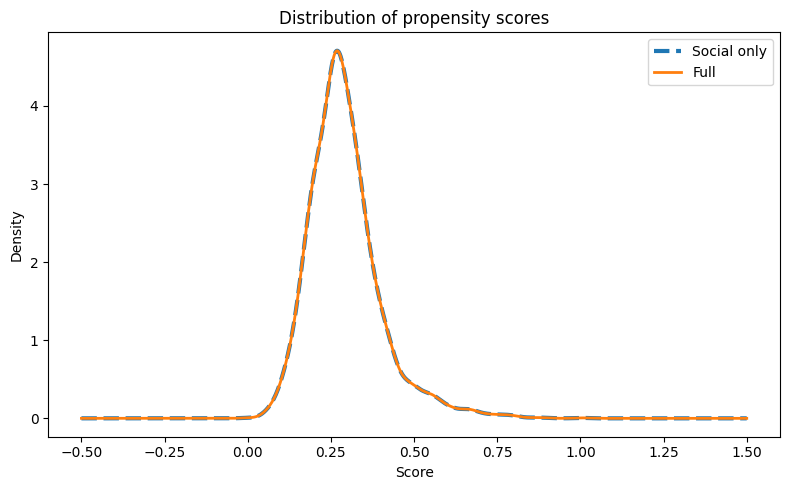

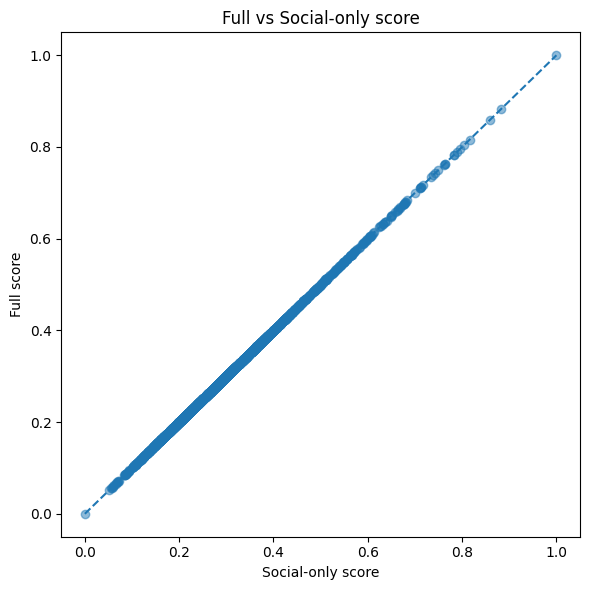

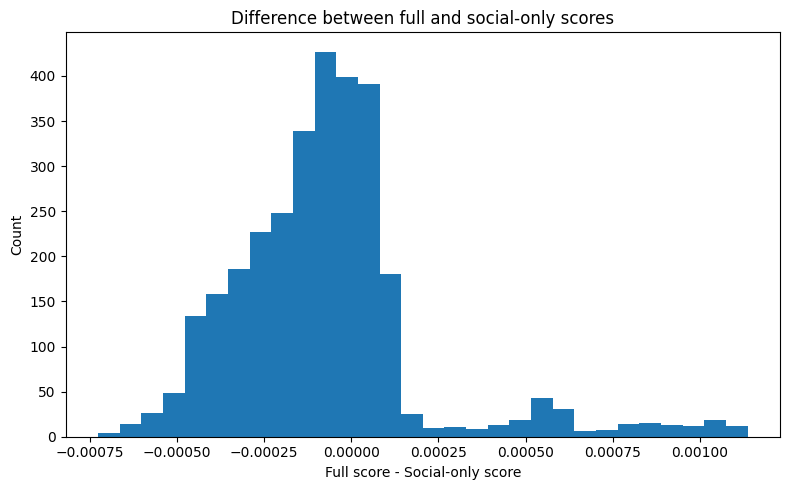

Top 10 counties where full score is MUCH HIGHER than social-only:


,county_name,social_score,full_score,diff,abs_diff
2483,"Andrews, Texas",0.455354,0.456491,0.001137,0.001137
2729,"Winkler, Texas",0.365573,0.366706,0.001133,0.001133
2568,"Glasscock, Texas",0.511900,0.513009,0.001109,0.001109
2533,"Crane, Texas",0.363985,0.365083,0.001098,0.001098
2676,"Reeves, Texas",0.269738,0.270832,0.001094,0.001094
2732,"Yoakum, Texas",0.402772,0.403860,0.001089,0.001089
2549,"Ector, Texas",0.342997,0.344083,0.001086,0.001086
2719,"Ward, Texas",0.354377,0.355461,0.001084,0.001084
2564,"Gaines, Texas",0.362819,0.363902,0.001083,0.001083
1769,"Lea, New Mexico",0.324167,0.325245,0.001077,0.001077


Top 10 counties where full score is LOWER than social-only:


,county_name,social_score,full_score,diff,abs_diff
554,"Shoshone, Idaho",0.186883,0.186157,-0.000726,0.000726
1589,"Mineral, Montana",0.240678,0.239965,-0.000714,0.000714
1585,"Lincoln, Montana",0.177578,0.176903,-0.000676,0.000676
2927,"Jefferson, Washington",0.306667,0.305995,-0.000673,0.000673
532,"Clearwater, Idaho",0.241151,0.240495,-0.000656,0.000656
2939,"San Juan, Washington",0.368389,0.367734,-0.000655,0.000655
525,"Boundary, Idaho",0.244415,0.243777,-0.000638,0.000638
1937,"Swain, North Carolina",0.225675,0.225037,-0.000638,0.000638
539,"Idaho, Idaho",0.217563,0.216926,-0.000637,0.000637
1573,"Flathead, Montana",0.332701,0.332073,-0.000629,0.000629


In [20]:
import matplotlib.pyplot as plt

compare = df[["county_name", "social_score", "full_score"]].copy()
compare["diff"] = compare["full_score"] - compare["social_score"]
compare["abs_diff"] = compare["diff"].abs()

# KDE-style line plot using pandas
fig, ax = plt.subplots(figsize=(8, 5))
compare["social_score"].plot(kind="kde", ax=ax, label="Social only", linestyle="--", linewidth=3)
compare["full_score"].plot(kind="kde", ax=ax, label="Full", linewidth=2)
ax.set_title("Distribution of propensity scores")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(compare["social_score"], compare["full_score"], alpha=0.5)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Full vs Social-only score")
ax.set_xlabel("Social-only score")
ax.set_ylabel("Full score")
plt.tight_layout()
plt.show()

# Difference histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(compare["diff"].dropna(), bins=30)
ax.set_title("Difference between full and social-only scores")
ax.set_xlabel("Full score - Social-only score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Counties with largest positive / negative change
print("Top 10 counties where full score is MUCH HIGHER than social-only:")
display(compare.sort_values("diff", ascending=False).head(10))

print("Top 10 counties where full score is LOWER than social-only:")
display(compare.sort_values("diff", ascending=True).head(10))